In [1]:
import numpy as np
import sounddevice as sd 
import lightkurve as lk
import matplotlib.pyplot as plt 

/Users/asmessier/miniconda3/envs/transitsong/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [61]:
tic = 124029677 
sector = 33

search_result = lk.search_lightcurve(
        f"TIC {tic}",
        mission="TESS",
        author="SPOC",
        sector =[sector]
    )

lc = search_result.download()


In [71]:
lc_binned = lc.bin(time_bin_size=0.01)

In [72]:
lc_fluxes = lc_binned.flux.value
lc_times = lc_binned.time.value


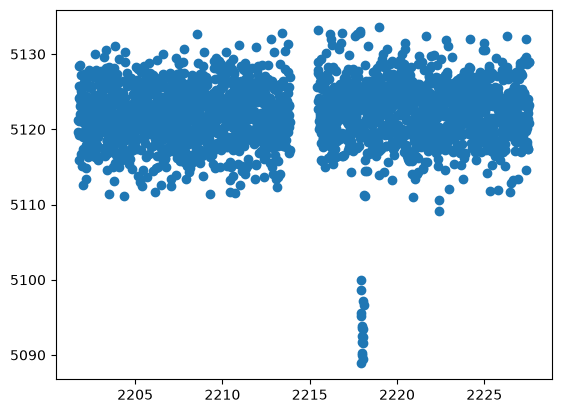

In [73]:
plt.scatter(lc_times, lc_fluxes)

In [83]:
len(lc_times)

2584

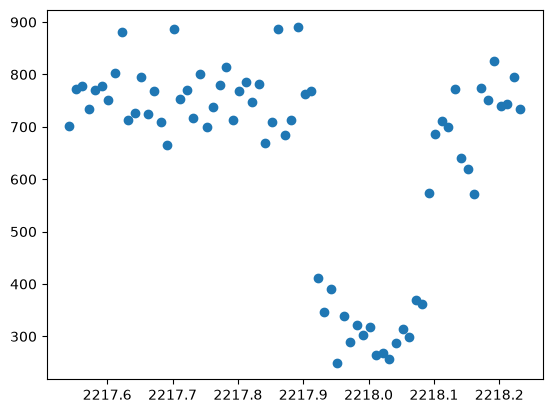

In [108]:
med_value = np.median(lc_fluxes)
lc_normflux = lc_fluxes/med_value

#central_val = 440 # hz 
max_val =900
min_val = 250

mapped_flux = (lc_normflux - np.min(lc_normflux)) / (np.max(lc_normflux) - np.min(lc_normflux)) * (max_val - min_val) + min_val

plt.scatter(lc_times[1580:1650], mapped_flux[1580:1650])

In [109]:
# for a loop
freq_maps = ()

samplerate = 44100
duration = 0.05

for flux in mapped_flux[1580:1650]:
    frequency = flux 
    t = np.linspace(0, duration, int(samplerate * duration), endpoint=False)
    
    audio_signal = 0.5 * np.sin(2*np.pi*frequency*t)

    sd.play(audio_signal, samplerate)
    sd.wait()


In [98]:
from scipy.io.wavfile import write

In [110]:
samplerate = 44100
duration = 0.05

audio = []

for flux in mapped_flux[1580:1650]:
    frequency = flux 
    t = np.linspace(0, duration, int(samplerate * duration), endpoint=False)
    
    audio_signal = np.sin(2*np.pi*frequency*t)
    
    audio.extend(audio_signal)

arr = np.array(audio)
    

In [111]:
sd.play(arr, samplerate)
sd.wait()